# Prototyp vs. MQA: Indikator-Level-Vergleich

Reproduzierbarer Vergleich des Prototyps gegen den MQA-Baseline-Scorer auf identischem Input.
Logik in `src/evaluation/indicator_join.py`, Mapping in `src/evaluation/indicator_map.py`,
Konzept in `docs/evaluation_vs_mqa.md`.

**Drei Evidenzstücke:**
- **[A] Konvergenz (H1)** — Übereinstimmungsrate auf den geteilten strukturellen Checks
- **[B] Überschätzung (H2)** — `MQA PASS & Prototyp FAIL/PARTIAL` je Indikator
- **[C] Blindheit (H2)** — Prototyp-Score-Verteilung wo MQA keine Metrik hat

> **Vor dem Lauf:** `OPENROUTER_API_KEY` in `.env` für die expressiveness-Indikatoren (C).
> Ohne Key: `USE_LLM = False` setzen — die C-expr-Tabelle bleibt dann leer.

In [3]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / 'src').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from dotenv import load_dotenv
load_dotenv(REPO / '.env')

import pandas as pd
from IPython.display import display

# ===================== Parameter =====================
SAMPLE_DIR = REPO / 'data' / 'sample_2026-06-18_13-45'  # <- Stichproben-Verzeichnis
USE_LLM    = False    # False: expr_*-Indikatoren = not_applicable (kein Token-Verbrauch)
USE_PROBE  = True    # False: HTTP-Checks deaktiviert (offline/schnell)
RECOMPUTE  = True   # True: Caches ignorieren und neu scoren
# =====================================================
print('REPO      :', REPO)
print('SAMPLE    :', SAMPLE_DIR, '|', len(list(SAMPLE_DIR.glob('*.rdf'))), 'RDF-Dateien')
print('LLM       :', 'an' if USE_LLM else 'aus (expr_* = N/A)')
print('HTTP-Probe:', 'an' if USE_PROBE else 'aus')

REPO      : /home/lbuerger/masterthesis/master_thesis_prototype
SAMPLE    : /home/lbuerger/masterthesis/master_thesis_prototype/data/sample_2026-06-18_13-45 | 48 RDF-Dateien
LLM       : aus (expr_* = N/A)
HTTP-Probe: an


## 1. Beide Modelle scoren (mit Cache)

Erster Lauf: beide Scorer laufen parallel auf jeder RDF-Datei.
Ergebnis wird in `model_indicators.csv` + `mqa_metrics.csv` gecacht — erneutes Ausführen
lädt den Cache (kein erneuter Token-Verbrauch), außer `RECOMPUTE = True`.

In [4]:
from evaluation import ground_truth as gt
from evaluation import indicator_join as ij

llm = gt.make_llm() if USE_LLM else None

res = ij.build_all(
    SAMPLE_DIR,
    llm=llm,
    probe=USE_PROBE,
    recompute=RECOMPUTE,
)
join = res['join']
print(f"join: {len(join)} Zeilen  ({join['file'].nunique()} Datensätze × {join['indicator'].nunique()} Indikatoren)")
print(f"A/B/C-Verteilung: {res['class_counts']}")
if res['unmapped_indicators']:
    print('UNMAPPED:', res['unmapped_indicators'], '← bitte in indicator_map.py eintragen')

[model  1/48] geo_gdi-de.rdf
[model  2/48] geo_gdi-de_02.rdf
[model  3/48] geo_gdi-de_03.rdf
[model  4/48] geo_gdi-de_05.rdf
[model  5/48] geo_open-data-brandenburg.rdf
[model  6/48] geo_open-data-brandenburg_02.rdf
[model  7/48] geo_open-data-brandenburg_03.rdf
[model  8/48] geo_open-data-brandenburg_04.rdf
[model  9/48] geo_open-data-brandenburg_05.rdf
[model 10/48] geo_open-data-portal-rheinland-pfalz.rdf
[model 11/48] geo_open-data-portal-rheinland-pfalz_02.rdf
[model 12/48] geo_open-data-portal-rheinland-pfalz_03.rdf
[model 13/48] geo_open-data-portal-rheinland-pfalz_04.rdf
[model 14/48] geo_open-data-portal-rheinland-pfalz_05.rdf
[model 15/48] geo_rest.rdf
[model 16/48] geo_rest_02.rdf
[model 17/48] geo_rest_03.rdf
[model 18/48] geo_rest_04.rdf
[model 19/48] geo_rest_05.rdf
[model 20/48] geo_transparenzportal-hamburg.rdf
[model 21/48] geo_transparenzportal-hamburg_02.rdf


Failed to convert Literal lexical form to value. Datatype=http://www.w3.org/2001/XMLSchema#hexBinary, Converter=<function _unhexlify at 0x7640dd112e80>
Traceback (most recent call last):
  File "/home/lbuerger/masterthesis/master_thesis_prototype/.venv/lib/python3.12/site-packages/rdflib/term.py", line 2262, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/home/lbuerger/masterthesis/master_thesis_prototype/.venv/lib/python3.12/site-packages/rdflib/term.py", line 1847, in _unhexlify
    return unhexlify(value)
           ^^^^^^^^^^^^^^^^
binascii.Error: Odd-length string


[model 22/48] geo_transparenzportal-hamburg_03.rdf


Failed to convert Literal lexical form to value. Datatype=http://www.w3.org/2001/XMLSchema#hexBinary, Converter=<function _unhexlify at 0x7640dd112e80>
Traceback (most recent call last):
  File "/home/lbuerger/masterthesis/master_thesis_prototype/.venv/lib/python3.12/site-packages/rdflib/term.py", line 2262, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/home/lbuerger/masterthesis/master_thesis_prototype/.venv/lib/python3.12/site-packages/rdflib/term.py", line 1847, in _unhexlify
    return unhexlify(value)
           ^^^^^^^^^^^^^^^^
binascii.Error: Odd-length string


[model 23/48] geo_transparenzportal-hamburg_04.rdf
[model 24/48] geo_transparenzportal-hamburg_05.rdf
[model 25/48] non_geo_gdi-de.rdf
[model 26/48] non_geo_gdi-de_02.rdf
[model 27/48] non_geo_gdi-de_03.rdf
[model 28/48] non_geo_gdi-de_04.rdf
[model 29/48] non_geo_gdi-de_05.rdf
[model 30/48] non_geo_land-schleswig-holstein.rdf
text/csv
application/json
text/csv
application/pdf
[model 31/48] non_geo_land-schleswig-holstein_02.rdf
text/csv
[model 32/48] non_geo_land-schleswig-holstein_03.rdf
application/json
[model 33/48] non_geo_land-schleswig-holstein_04.rdf
text/csv
[model 34/48] non_geo_land-schleswig-holstein_05.rdf
[model 35/48] non_geo_open-data-bayern.rdf
text/csv
text/xml
text/csv
text/xlsx
[model 36/48] non_geo_open-data-bayern_02.rdf
text/csv
text/csv
text/xlsx
text/xml
[model 37/48] non_geo_open-data-bayern_03.rdf
[model 38/48] non_geo_open-data-bayern_04.rdf
text/csv
text/xml
text/xlsx
text/csv
[model 39/48] non_geo_open-data-bayern_05.rdf
[model 40/48] non_geo_open-data-bra

Failed to convert Literal lexical form to value. Datatype=http://www.w3.org/2001/XMLSchema#hexBinary, Converter=<function _unhexlify at 0x7640dd112e80>
Traceback (most recent call last):
  File "/home/lbuerger/masterthesis/master_thesis_prototype/.venv/lib/python3.12/site-packages/rdflib/term.py", line 2262, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/home/lbuerger/masterthesis/master_thesis_prototype/.venv/lib/python3.12/site-packages/rdflib/term.py", line 1847, in _unhexlify
    return unhexlify(value)
           ^^^^^^^^^^^^^^^^
binascii.Error: Odd-length string


[MQA 22/48] geo_transparenzportal-hamburg_03.rdf
[MQA 23/48] geo_transparenzportal-hamburg_04.rdf
[MQA 24/48] geo_transparenzportal-hamburg_05.rdf
[MQA 25/48] non_geo_gdi-de.rdf
[MQA 26/48] non_geo_gdi-de_02.rdf
[MQA 27/48] non_geo_gdi-de_03.rdf
[MQA 28/48] non_geo_gdi-de_04.rdf
[MQA 29/48] non_geo_gdi-de_05.rdf
[MQA 30/48] non_geo_land-schleswig-holstein.rdf
[MQA 31/48] non_geo_land-schleswig-holstein_02.rdf
[MQA 32/48] non_geo_land-schleswig-holstein_03.rdf
[MQA 33/48] non_geo_land-schleswig-holstein_04.rdf
[MQA 34/48] non_geo_land-schleswig-holstein_05.rdf
[MQA 35/48] non_geo_open-data-bayern.rdf
[MQA 36/48] non_geo_open-data-bayern_02.rdf
[MQA 37/48] non_geo_open-data-bayern_03.rdf
[MQA 38/48] non_geo_open-data-bayern_04.rdf
[MQA 39/48] non_geo_open-data-bayern_05.rdf
[MQA 40/48] non_geo_open-data-brandenburg.rdf
[MQA 41/48] non_geo_open-data-brandenburg_02.rdf
[MQA 42/48] non_geo_open-data-brandenburg_03.rdf
[MQA 43/48] non_geo_open-data-brandenburg_04.rdf
[MQA 44/48] non_geo_open

## 2. A/B/C-Mapping-Übersicht

Alle Indikatoren, ihr MQA-Gegenpart und die Klassifikation. `review=True` markiert
Grenzfälle, die gegen die MQA-Spec belegt werden müssen.

In [5]:
from evaluation.indicator_map import mapping_df, mqa_only_metrics

mdf = mapping_df()[['indicator','dimension','abc','mqa_str','review','rationale']]
mdf.columns = ['Indikator','Dimension','A/B/C','MQA-Metriken','Review?','Begründung']
display(mdf.sort_values(['A/B/C','Dimension']).reset_index(drop=True))

print('\nMQA prüft, Prototyp nicht (Balance §4.3):')
for m in mqa_only_metrics():
    print(f'  {m}')

,Indikator,Dimension,A/B/C,MQA-Metriken,Review?,Begründung
0,acc_download_url,accessibility,A,download_url_availability,False,Beide: Presence dcat:downloadURL.
1,acc_download_url_response,accessibility,A,download_url_status_code,False,Beide: HTTP-Auflösbarkeit der downloadURL (<400).
2,acc_access_url_response,accessibility,A,access_url_status_code,False,Beide: HTTP-Auflösbarkeit der accessURL (<400).
3,acc_format_non_proprietary,accessibility,A,format_non_proprietary,False,Beide: nicht-proprietäres Format-URI aus EU-Vo...
4,find_temporal_coverage,findability,A,temporal_availability,True,Beide: zeitliche Abdeckung (start/end). Protot...
5,find_issued_datetime,findability,A,date_issued_availability,True,Beide: Vorhandensein dct:issued. Prototyp prüf...
6,find_modified_datetime,findability,A,date_modified_availability,True,Beide: Vorhandensein dct:modified. Prototyp pr...
7,reuse_dcat_ap_de_compliance,reusability,A,dcat_ap_compliance,False,Beide: DCAT-AP SHACL-Konformität via ITB-API (...
8,reuse_access_rights,reusability,A,access_rights_availability;access_rights_vocab...,True,Beide: accessRights vorhanden + Vokabular.
9,acc_format,accessibility,B,format_availability;format_media_type_vocabulary,True,MQA: Format vorhanden + format_media_type_voca...



MQA prüft, Prototyp nicht (Balance §4.3):
  rights_availability
  byte_size_availability


## 3. [A] Konvergenz (H1)

Auf den **äquivalenten** Checks (A): stimmen MQA und Prototyp überein?
Erwartung: hohe Agreement-Rate → der Prototyp bildet die etablierte MQA-Logik korrekt ab.

In [6]:
a = res['class_a']
if a['n'] == 0:
    print('Keine A-Paare vorhanden.')
else:
    print(f"[A] Konvergenz: {a['agreement']:.1%}  (n={a['n']} file×indicator-Paare)")
    print()
    contingency = pd.DataFrame({
        '': ['MQA PASS', 'MQA FAIL'],
        'Prototyp PASS': [a['both_pass'],       a['model_pass_mqa_fail']],
        'Prototyp FAIL': [a['mqa_pass_model_fail'], a['both_fail']],
    }).set_index('')
    display(contingency)

    # Per-A-Indikator aufschlüsseln
    a_detail = (
        join[join['abc'] == 'A']
        .assign(
            agree=lambda d: d['model_pass'] == d['mqa_pass'],
            mpf=lambda d: (d['mqa_pass'] == 1) & (d['model_pass'] == 0),
        )
        .groupby('indicator')
        .agg(n=('agree', 'count'), agreement=('agree', 'mean'), mqa_pass_model_fail=('mpf', 'sum'))
    )
    display(a_detail.round(2))

[A] Konvergenz: 85.6%  (n=432 file×indicator-Paare)



,Prototyp PASS,Prototyp FAIL
,,
MQA PASS,249,52
MQA FAIL,10,121


,n,agreement,mqa_pass_model_fail
indicator,,,
acc_access_url_response,48,0.92,4
acc_download_url,48,1.00,0
acc_download_url_response,48,1.00,0
acc_format_non_proprietary,48,0.79,8
find_issued_datetime,48,1.00,0
find_modified_datetime,48,1.00,0
find_temporal_coverage,48,1.00,0
reuse_access_rights,48,0.83,0
reuse_dcat_ap_de_compliance,48,0.17,40


## 4. [B] Überschätzung durch MQA (H2)

Indikatoren, bei denen MQA = **PASS** (Presence genügt), der Prototyp aber **FAIL/PARTIAL**
(er prüft Gültigkeit/Tiefe/Kongruenz). Die obere linke Zelle einer Kontingenztabelle je
Indikator ist der direkte Beleg, dass MQA Qualität *annimmt*, die nicht da ist.

In [7]:
b = res['class_b']
if b.empty:
    print('Keine B-Fälle.')
else:
    b_display = b.copy()
    b_display['überschätzung'] = b_display['overestimation_rate'].map('{:.0%}'.format)
    b_display['review?'] = b_display['review'].map({True: '⚠', False: ''})
    display(b_display[['indicator','n','mqa_pass_model_fail','überschätzung',
                        'both_pass','both_fail','model_pass_mqa_fail','review?']])

,indicator,n,mqa_pass_model_fail,überschätzung,both_pass,both_fail,model_pass_mqa_fail,review?
0,find_adminunitl2,48,28,58%,9,11,0,
1,find_keywords_count,48,19,40%,29,0,0,⚠
2,reuse_contact,48,14,29%,20,14,0,
3,acc_media_type,48,9,19%,6,33,0,⚠
4,find_locn_geometry,48,8,17%,29,11,0,
5,acc_machine_readable_access,48,2,4%,11,28,7,
6,reuse_license,48,2,4%,46,0,0,⚠
7,acc_format,48,1,2%,31,16,0,⚠
8,find_theme_valid,48,0,0%,45,3,0,
9,reuse_publisher,48,0,0%,48,0,0,


In [8]:
# Beispieldatensätze: MQA PASS & Prototyp FAIL für den stärksten B-Indikator
if not b.empty:
    top_ind = b.iloc[0]['indicator']
    print(f'Disagreement-Fälle für {top_ind} (MQA=PASS, Prototyp=FAIL):')
    cases = join[
        (join['indicator'] == top_ind) &
        (join['mqa_pass'] == 1) &
        (join['model_pass'] == 0)
    ][['file','model_status','model_score']]
    display(cases.reset_index(drop=True))

Disagreement-Fälle für find_adminunitl2 (MQA=PASS, Prototyp=FAIL):


,file,model_status,model_score
0,geo_gdi-de.rdf,fail,0.0
1,geo_gdi-de_02.rdf,fail,0.0
2,geo_gdi-de_03.rdf,fail,0.0
3,geo_gdi-de_05.rdf,fail,0.0
4,geo_open-data-brandenburg.rdf,fail,0.0
5,geo_open-data-brandenburg_02.rdf,fail,0.0
6,geo_open-data-brandenburg_03.rdf,fail,0.0
7,geo_open-data-brandenburg_04.rdf,fail,0.0
8,geo_open-data-brandenburg_05.rdf,fail,0.0
9,geo_rest.rdf,fail,0.0


## 5. [C] Strukturelle Blindheit der MQA (H2)

Für C-Indikatoren hat MQA **keine Metrik** — ihr Score ist konstruktiv flach (keine Reaktion).
Die Spalte `model_score_std` zeigt, ob der Prototyp hier tatsächlich variiert (= er erkennt
Unterschiede, die MQA per Design nicht sehen kann).

In [9]:
c = res['class_c']
if c.empty:
    print('Keine C-Scores — entweder USE_LLM=False oder alle C-Indikatoren = not_applicable.')
else:
    c_display = c[['indicator','n','model_score_mean','model_score_std',
                   'model_score_min','model_score_max','n_below_0_5']].copy()
    c_display.columns = ['Indikator','n','Mittel','Std','Min','Max','<0.5']
    display(c_display.round(3))

,Indikator,n,Mittel,Std,Min,Max,<0.5
0,expr_description_quality,48,0.000,0.000,0.0,0.0,48
1,expr_contextual_qualifiers,48,0.000,0.000,0.0,0.0,48
2,expr_thematic_consistency,48,0.000,0.000,0.0,0.0,48
3,expr_keyword_quality,48,0.000,0.000,0.0,0.0,48
4,expr_title_description_coherence,48,0.000,0.000,0.0,0.0,48
5,expr_title_quality,48,0.000,0.000,0.0,0.0,48
6,find_accrual_periodicity,48,0.281,0.420,0.0,1.0,32
7,acc_format_congruence,48,0.710,0.352,0.0,1.0,10
8,acc_distribution_model,48,0.871,0.250,0.0,1.0,3
9,reuse_contributor_id,48,0.875,0.331,0.0,1.0,6


## 6. Grafiken

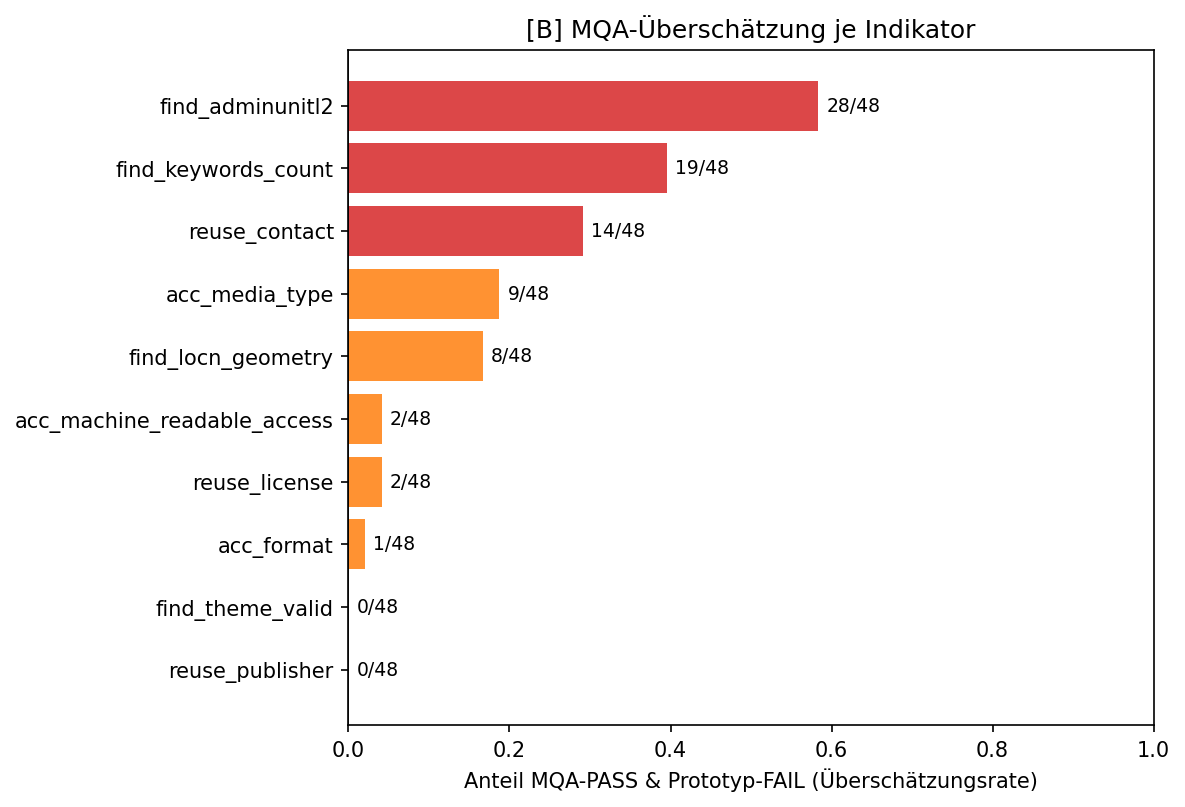

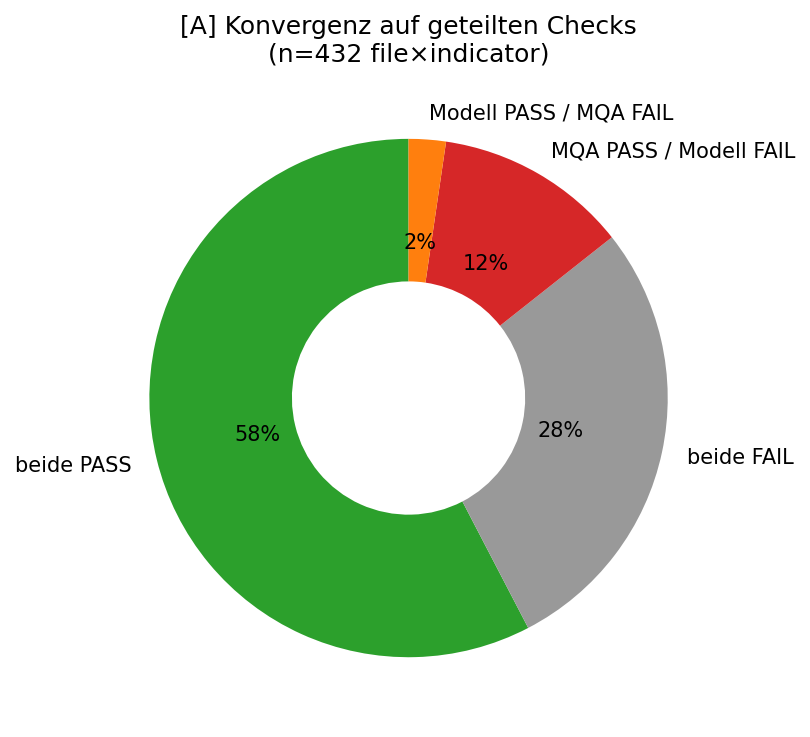

/tmp/ipykernel_60216/782098113.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(c_data, labels=[i.replace('expr_', 'expr\n') for i in c_inds_filtered],


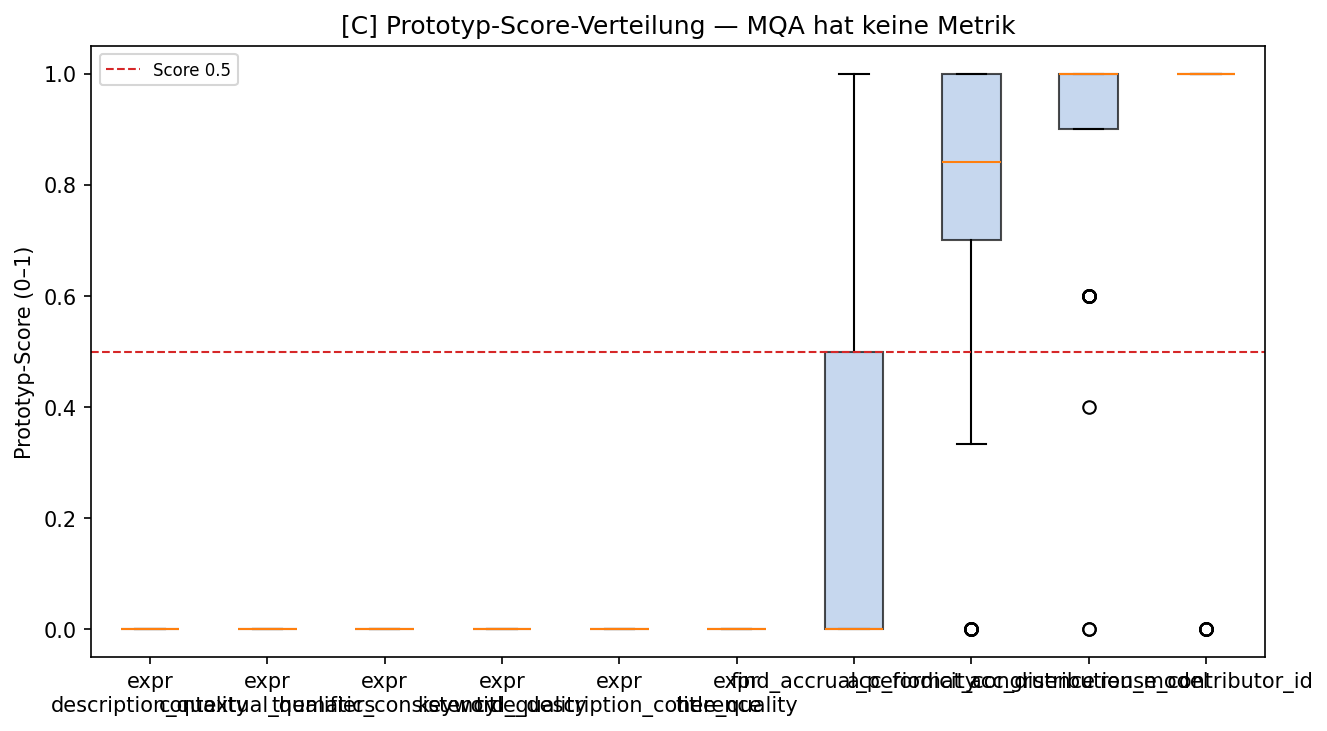

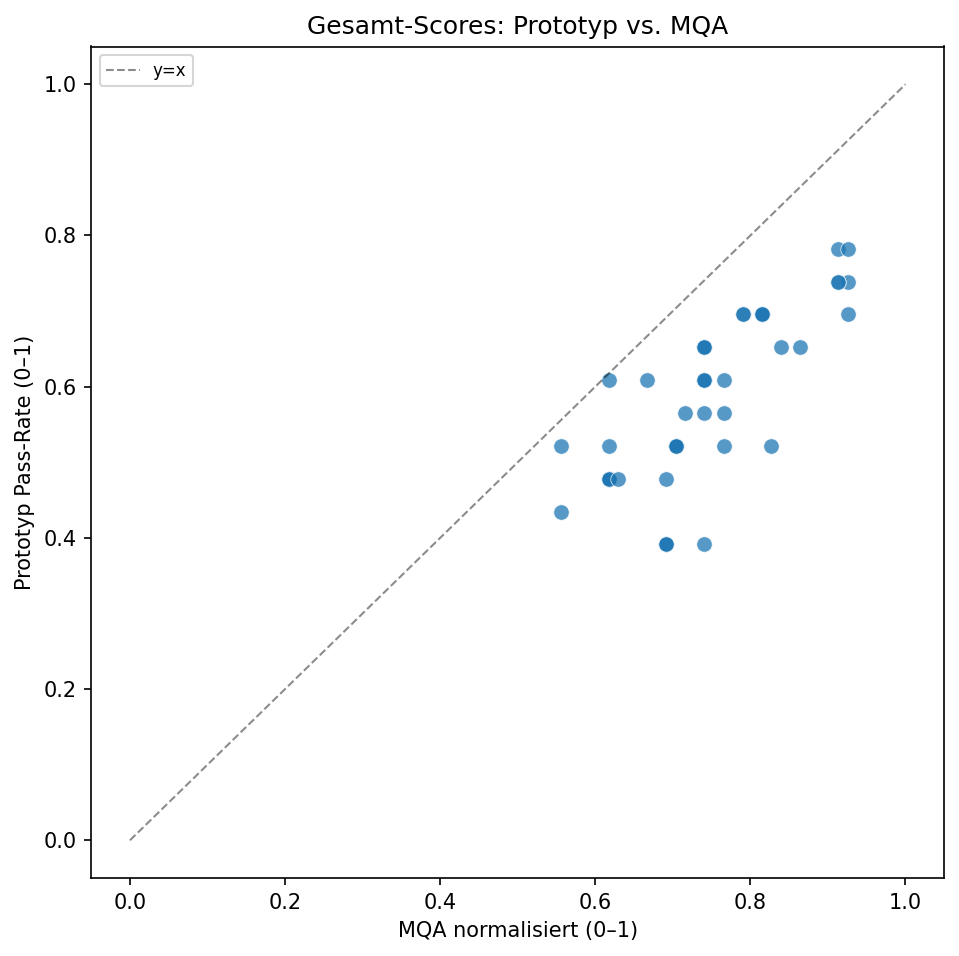


Grafiken gespeichert:
  /home/lbuerger/masterthesis/master_thesis_prototype/data/sample_2026-06-18_13-45/mqa_comparison_figures/b_overestimation.png
  /home/lbuerger/masterthesis/master_thesis_prototype/data/sample_2026-06-18_13-45/mqa_comparison_figures/a_agreement_donut.png
  /home/lbuerger/masterthesis/master_thesis_prototype/data/sample_2026-06-18_13-45/mqa_comparison_figures/c_blindness_boxplot.png
  /home/lbuerger/masterthesis/master_thesis_prototype/data/sample_2026-06-18_13-45/mqa_comparison_figures/overall_scatter.png


In [10]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display as disp
from pathlib import Path

FIG_DIR = SAMPLE_DIR / 'mqa_comparison_figures'
FIG_DIR.mkdir(exist_ok=True)
saved = []

def save(fig, name):
    p = FIG_DIR / f'{name}.png'
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.close(fig)
    saved.append(p)
    return p


# 1. B: Überschätzungsrate je B-Indikator (horizontale Balken)
if not b.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(b) * 0.55)))
    colors = ['#d62728' if r > 0.25 else '#ff7f0e' if r > 0 else '#aec7e8'
              for r in b['overestimation_rate']]
    ax.barh(b['indicator'], b['overestimation_rate'], color=colors, alpha=0.85)
    ax.set_xlabel('Anteil MQA-PASS & Prototyp-FAIL (Überschätzungsrate)')
    ax.set_xlim(0, 1)
    ax.axvline(0, color='k', lw=0.8)
    for i, (_, r) in enumerate(b.iterrows()):
        ax.text(r['overestimation_rate'] + 0.01, i,
                f"{int(r['mqa_pass_model_fail'])}/{int(r['n'])}", va='center', fontsize=9)
    ax.set_title('[B] MQA-Überschätzung je Indikator')
    ax.invert_yaxis()
    fig.tight_layout()
    save(fig, 'b_overestimation')
    disp(Image(str(FIG_DIR / 'b_overestimation.png')))


# 2. A: Übereinstimmungs-Donut
if a['n'] > 0:
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    vals = [a['both_pass'], a['both_fail'], a['mqa_pass_model_fail'], a['model_pass_mqa_fail']]
    labels = ['beide PASS', 'beide FAIL', 'MQA PASS / Modell FAIL', 'Modell PASS / MQA FAIL']
    colors = ['#2ca02c', '#999999', '#d62728', '#ff7f0e']
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors, autopct='%1.0f%%',
        startangle=90, wedgeprops=dict(width=0.55)
    )
    ax.set_title(f'[A] Konvergenz auf geteilten Checks\n(n={a["n"]} file×indicator)')
    fig.tight_layout()
    save(fig, 'a_agreement_donut')
    disp(Image(str(FIG_DIR / 'a_agreement_donut.png')))


# 3. C: Boxplot der Prototyp-Scores je C-Indikator
if not c.empty:
    c_inds = c['indicator'].tolist()
    c_data = [join.loc[(join['indicator'] == ind) & join['model_score'].notna(),
                       'model_score'].astype(float).tolist() for ind in c_inds]
    c_data = [d for d in c_data if d]
    c_inds_filtered = [ind for ind, d in zip(c_inds, c_data) if d]
    if c_data:
        fig, ax = plt.subplots(figsize=(max(6, len(c_data) * 0.9), 5))
        ax.boxplot(c_data, labels=[i.replace('expr_', 'expr\n') for i in c_inds_filtered],
                   patch_artist=True,
                   boxprops=dict(facecolor='#aec7e8', alpha=0.7))
        ax.axhline(0.5, color='#d62728', lw=1, ls='--', label='Score 0.5')
        ax.set_ylabel('Prototyp-Score (0–1)')
        ax.set_ylim(-0.05, 1.05)
        ax.set_title('[C] Prototyp-Score-Verteilung — MQA hat keine Metrik')
        ax.legend(fontsize=8)
        fig.tight_layout()
        save(fig, 'c_blindness_boxplot')
        disp(Image(str(FIG_DIR / 'c_blindness_boxplot.png')))


# 4. Gesamtübersicht: Score-Differenz (Prototyp normalisiert - MQA normalisiert) je Datensatz
# Für die Scatter-Ansicht: normalisierte Gesamt-Scores beider Modelle je Datensatz
mqa_totals = (
    join[join['mqa_pass'].notna()]
    .merge(
        pd.read_csv(SAMPLE_DIR / 'mqa_metrics.csv')[['file','mqa_max','mqa_points']]
        if 'mqa_points' in pd.read_csv(SAMPLE_DIR / 'mqa_metrics.csv').columns
        else pd.DataFrame(columns=['file','mqa_max','mqa_points']),
        on='file', how='left'
    )
)

# Simpler: aus dem mqa_metrics.csv die Gesamt-Summe je File ableiten
mqa_raw = pd.read_csv(SAMPLE_DIR / 'mqa_metrics.csv')
mqa_per_file = (
    mqa_raw.groupby('file')
    .apply(lambda g: pd.Series({
        'mqa_score_norm': g['mqa_points'].sum() / g['mqa_max'].sum() if g['mqa_max'].sum() > 0 else float('nan')
    }))
    .reset_index()
)

model_raw = pd.read_csv(SAMPLE_DIR / 'model_indicators.csv')
model_per_file = (
    model_raw[model_raw['model_pass'].notna()]
    .groupby('file')['model_pass']
    .mean()
    .reset_index()
    .rename(columns={'model_pass': 'model_score_norm'})
)

scatter_df = mqa_per_file.merge(model_per_file, on='file')

if not scatter_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.scatter(scatter_df['mqa_score_norm'], scatter_df['model_score_norm'],
               s=55, alpha=0.75, color='#1f77b4', edgecolors='white', lw=0.4)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.45, label='y=x')
    ax.set_xlabel('MQA normalisiert (0–1)')
    ax.set_ylabel('Prototyp Pass-Rate (0–1)')
    ax.set_title('Gesamt-Scores: Prototyp vs. MQA')
    ax.legend(fontsize=8)
    fig.tight_layout()
    save(fig, 'overall_scatter')
    disp(Image(str(FIG_DIR / 'overall_scatter.png')))

print('\nGrafiken gespeichert:')
for p in saved:
    print(' ', p)

## 7. Disagreement-Analyse

Datensätze nach größter Score-Differenz ranken — die Top-Fälle zeigen **warum** die Modelle
auseinanderlaufen und liefern Material für die qualitative Diskussion (vgl. §6 `docs/evaluation_vs_mqa.md`).

In [11]:
if not scatter_df.empty:
    scatter_df['diff'] = scatter_df['model_score_norm'] - scatter_df['mqa_score_norm']
    scatter_df['abs_diff'] = scatter_df['diff'].abs()
    print('=== Top Disagreements (|Prototyp - MQA| größte Abweichung) ===')
    display(
        scatter_df.sort_values('abs_diff', ascending=False)
        [['file','mqa_score_norm','model_score_norm','diff']]
        .rename(columns={'mqa_score_norm':'MQA','model_score_norm':'Prototyp','diff':'Δ (Prot-MQA)'})
        .round(3)
        .head(15)
        .reset_index(drop=True)
    )

    # Für jeden Top-Disagrement: welche B-Indikatoren sind Schuld?
    top_file = scatter_df.sort_values('abs_diff', ascending=False).iloc[0]['file']
    print(f'\nB-Indikatoren für "{top_file}":')
    display(
        join[
            (join['file'] == top_file) & (join['abc'] == 'B')
        ][['indicator','model_status','model_score','mqa_metrics','mqa_pass']]
        .reset_index(drop=True)
    )

=== Top Disagreements (|Prototyp - MQA| größte Abweichung) ===


,file,MQA,Prototyp,Δ (Prot-MQA)
0,geo_rest_05.rdf,0.741,0.391,-0.349
1,geo_rest_04.rdf,0.827,0.522,-0.305
2,non_geo_open-data-bayern_02.rdf,0.691,0.391,-0.300
3,non_geo_open-data-bayern_03.rdf,0.691,0.391,-0.300
4,non_geo_open-data-bayern_05.rdf,0.691,0.391,-0.300
5,geo_rest_02.rdf,0.765,0.522,-0.244
6,non_geo_land-schleswig-holstein_02.rdf,0.926,0.696,-0.230
7,non_geo_rest_05.rdf,0.691,0.478,-0.213
8,geo_open-data-brandenburg_04.rdf,0.864,0.652,-0.212
9,geo_gdi-de_05.rdf,0.765,0.565,-0.200



B-Indikatoren für "geo_rest_05.rdf":


,indicator,model_status,model_score,mqa_metrics,mqa_pass
0,acc_format,partial,0.5000,format_availability;format_media_type_vocabulary,1.0
1,acc_media_type,fail,0.0000,media_type_availability;format_media_type_voca...,0.0
2,acc_machine_readable_access,partial,0.5714,format_machine_readable,1.0
3,find_keywords_count,pass,1.0000,keyword_availability,1.0
4,find_theme_valid,pass,1.0000,category_availability,1.0
5,find_locn_geometry,fail,0.0000,spatial_availability,1.0
6,find_adminunitl2,pass,1.0000,spatial_availability,1.0
7,reuse_license,pass,1.0000,license_availability;known_license,1.0
8,reuse_publisher,pass,1.0000,publisher_availability,1.0
9,reuse_contact,partial,0.5500,contact_point_availability,1.0


## 8. Zusammenfassung

Kompakte Übersicht aller Headline-Zahlen für die Thesis.

In [12]:
print('=== Zusammenfassung Prototyp vs. MQA ===')
print(f'Stichprobe : {join["file"].nunique()} Datensätze, {join["indicator"].nunique()} Indikatoren')
print(f'A/B/C      : {res["class_counts"]}')
print()
if a['n']:
    print(f'[A] Konvergenz   : {a["agreement"]:.1%}  (MQA-PASS/Modell-FAIL: {a["mqa_pass_model_fail"]}, '
          f'Modell-PASS/MQA-FAIL: {a["model_pass_mqa_fail"]})')

if not b.empty:
    total_overest = int(b['mqa_pass_model_fail'].sum())
    total_b_cases = int(b['n'].sum())
    print(f'[B] Überschätzung: {total_overest}/{total_b_cases} B-Fälle ({total_overest/total_b_cases:.1%}) '
          f'MQA-PASS & Prototyp-FAIL')
    top = b.iloc[0]
    print(f'   Stärkster B-Indikator: {top["indicator"]} ({int(top["mqa_pass_model_fail"])}/{int(top["n"])}, '
          f'{top["overestimation_rate"]:.0%})')

if not c.empty:
    n_active_c = int(c['n_below_0_5'].sum())
    n_total_c = int(c['n'].sum())
    print(f'[C] Blindheit    : {c["indicator"].nunique()} Indikatoren ohne MQA-Pendant, '
          f'{n_active_c}/{n_total_c} Fälle Score<0.5')

print(f'\nMQA-only-Metriken (Prototyp nicht): {res["mqa_only_metrics"]}')
if res['unmapped_indicators']:
    print(f'Unmapped: {res["unmapped_indicators"]}')

=== Zusammenfassung Prototyp vs. MQA ===
Stichprobe : 48 Datensätze, 29 Indikatoren
A/B/C      : {'B': 10, 'C': 10, 'A': 9}

[A] Konvergenz   : 85.6%  (MQA-PASS/Modell-FAIL: 52, Modell-PASS/MQA-FAIL: 10)
[B] Überschätzung: 83/480 B-Fälle (17.3%) MQA-PASS & Prototyp-FAIL
   Stärkster B-Indikator: find_adminunitl2 (28/48, 58%)
[C] Blindheit    : 10 Indikatoren ohne MQA-Pendant, 339/480 Fälle Score<0.5

MQA-only-Metriken (Prototyp nicht): ['rights_availability', 'byte_size_availability']
